# 01｜认识序列与三维张量

图片通常写成 `[Batch, Channel, Height, Width]`，序列则常写成 `[Batch, Time, Feature]`。本页把这三个轴和实际数据一一对齐。

In [1]:
%matplotlib inline
from pathlib import Path
import sys
import torch

LAB_DIR = Path.cwd()
if not (LAB_DIR / "rnn_lab").is_dir():
    LAB_DIR = (LAB_DIR / "03_rnn_lab").resolve()
if str(LAB_DIR) not in sys.path:
    sys.path.insert(0, str(LAB_DIR))

# 共享服务器约定：每个 Notebook 只占用一个 CPU 计算线程。
torch.set_num_threads(1)

from rnn_lab import make_delayed_recall_data, plot_sequence_sample, plot_tensor_structure

## 先从一条序列开始

- `Time` 表示先后顺序，交换时间步会改变问题；
- `Feature` 表示同一时间步记录了哪些数值；
- `Batch` 表示一次送进模型多少条序列。

X_train shape: (12, 12, 6)
y_train shape: (12,)
一条序列 shape: (12, 6)
一个时间步 shape: (6,)


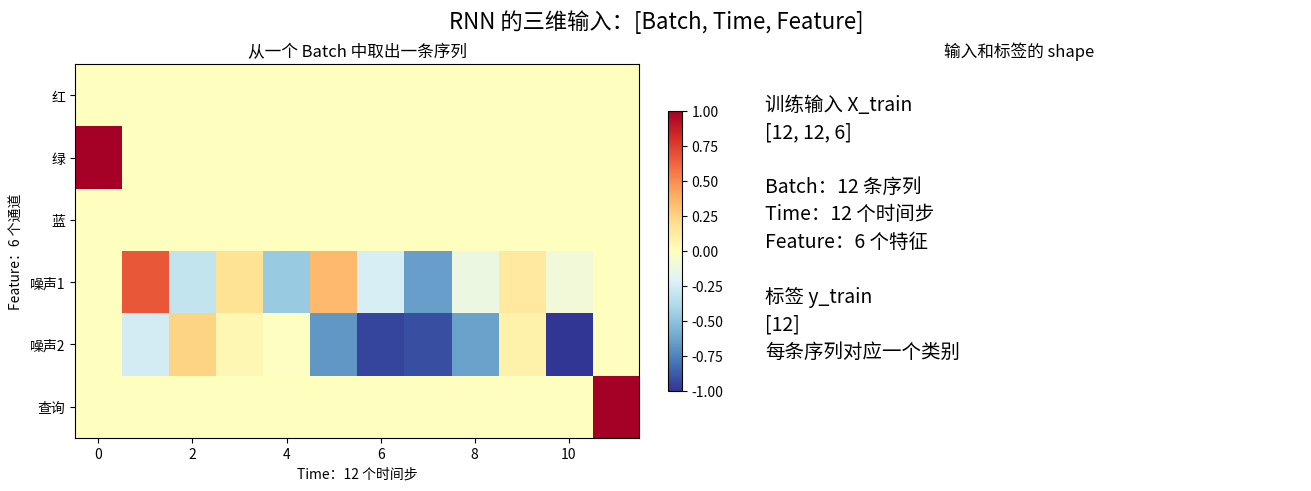

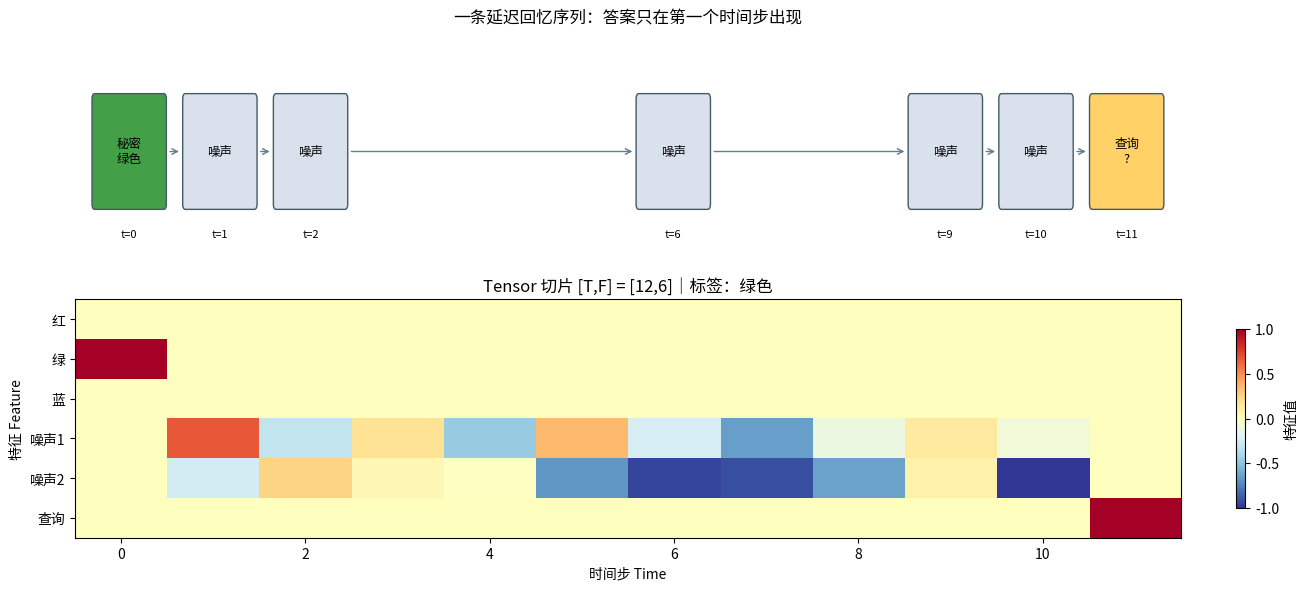

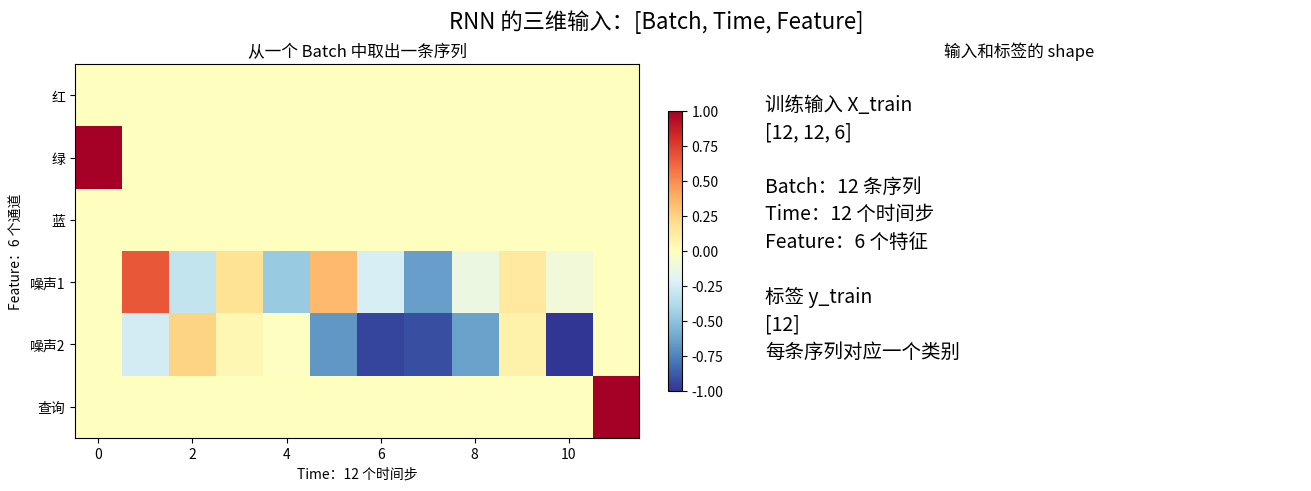

In [2]:
data = make_delayed_recall_data(
    sequence_length=12, train_size=12, val_size=6, test_size=6, seed=7
)
print("X_train shape:", tuple(data.x_train.shape))
print("y_train shape:", tuple(data.y_train.shape))
print("一条序列 shape:", tuple(data.x_train[0].shape))
print("一个时间步 shape:", tuple(data.x_train[0, 0].shape))

plot_sequence_sample(data.x_train, data.y_train, index=0)
plot_tensor_structure(data, index=0)

## 用索引验证三个轴

不要只背 `[B,T,F]`。下面分别固定两个轴，观察剩下的轴代表什么。

In [3]:
print("第 0 条完整序列 X[0]：", tuple(data.x_train[0].shape), "= [T,F]")
print("所有序列的第 0 步 X[:,0]：", tuple(data.x_train[:, 0].shape), "= [B,F]")
print("所有序列所有时间的查询通道 X[:,:,5]：", tuple(data.x_train[:, :, 5].shape), "= [B,T]")

assert data.x_train.ndim == 3
assert data.y_train.ndim == 1
assert data.x_train.shape[0] == data.y_train.shape[0]
print("shape 检查通过。")

第 0 条完整序列 X[0]： (12, 6) = [T,F]
所有序列的第 0 步 X[:,0]： (12, 6) = [B,F]
所有序列所有时间的查询通道 X[:,:,5]： (12, 12) = [B,T]
shape 检查通过。


## 小结

`batch_first=True` 只让输入和输出采用 `[B,T,F]`，隐藏状态仍然以“层/方向、Batch、隐藏维度”为顺序。下一页会观察隐藏状态怎样沿时间传递。

## 完成本页后：释放资源并结束内核

运行下面最后一个单元格会清空变量、关闭图片、释放未使用的 CUDA 缓存，并向 Jupyter 内核发送正常关机请求。

运行后 VS Code 显示“内核已停止”或要求重新选择内核属于正常现象。再次实验时重新选择课程内核即可。

In [ ]:
%reset -f
import gc
import matplotlib.pyplot as plt
import torch
from IPython import get_ipython

plt.close("all")
gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()

print("清理完成，正在结束当前 Notebook 的 Python 内核……")
get_ipython().kernel.do_shutdown(restart=False)